In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [5]:
import pandas as pd
import pyarrow.parquet as pq

path = "../datasets/NF-UQ-NIDS-v2.parquet"

# cek label (tetap cepat)
df = pd.read_parquet(path, columns=["Label"])
print(df["Label"].value_counts(normalize=True))

frac = 0.001

parquet_file = pq.ParquetFile(path)

samples = []

for i in range(parquet_file.num_row_groups):
    chunk = parquet_file.read_row_group(i).to_pandas()

    sampled_chunk = (
        chunk
        .groupby("Label", group_keys=False)
        .sample(frac=frac, random_state=42)
    )

    samples.append(sampled_chunk)

df_sample = pd.concat(samples, ignore_index=True)

print("Sample shape:", df_sample.shape)
print(df_sample["Label"].value_counts(normalize=True))

df_sample.to_parquet("../datasets/NF-UQ-NIDS-v2_sample.parquet", index=False)

Label
1    0.668825
0    0.331175
Name: proportion, dtype: float64
Sample shape: (75988, 46)
Label
1    0.669329
0    0.330671
Name: proportion, dtype: float64


In [6]:
df_sample.head()

,IPV4_SRC_ADDR,L4_SRC_PORT,IPV4_DST_ADDR,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,OUT_BYTES,OUT_PKTS,...,TCP_WIN_MAX_OUT,ICMP_TYPE,ICMP_IPV4_TYPE,DNS_QUERY_ID,DNS_QUERY_TYPE,DNS_TTL_ANSWER,FTP_COMMAND_RET_CODE,Label,Attack,Dataset
0,59.166.0.5,59081,149.171.126.8,5190,6,0.0,4908,34,2344,24,...,17376,48640,190,0,0,0,0.0,0,Benign,NF-UNSW-NB15-v2
1,125.166.152.146,62313,172.31.64.88,445,6,41.0,128,3,128,3,...,65340,0,0,0,0,0,0.0,0,Benign,NF-CSE-CIC-IDS2018-v2
2,172.31.68.28,60641,172.31.0.2,53,17,0.0,68,1,153,1,...,0,0,0,5645,28,60,0.0,0,Benign,NF-CSE-CIC-IDS2018-v2
3,185.222.211.110,18669,172.31.64.27,3389,6,0.0,1534,10,1873,7,...,64000,0,0,0,0,0,0.0,0,Benign,NF-CSE-CIC-IDS2018-v2
4,213.202.230.217,55429,172.31.65.68,3389,6,0.0,1915,14,1991,10,...,64000,0,0,0,0,0,0.0,0,Benign,NF-CSE-CIC-IDS2018-v2


In [7]:
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75988 entries, 0 to 75987
Data columns (total 46 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   IPV4_SRC_ADDR                75988 non-null  object 
 1   L4_SRC_PORT                  75988 non-null  int64  
 2   IPV4_DST_ADDR                75988 non-null  object 
 3   L4_DST_PORT                  75988 non-null  int64  
 4   PROTOCOL                     75988 non-null  int64  
 5   L7_PROTO                     75988 non-null  float64
 6   IN_BYTES                     75988 non-null  int64  
 7   IN_PKTS                      75988 non-null  int64  
 8   OUT_BYTES                    75988 non-null  int64  
 9   OUT_PKTS                     75988 non-null  int64  
 10  TCP_FLAGS                    75988 non-null  int64  
 11  CLIENT_TCP_FLAGS             75988 non-null  int64  
 12  SERVER_TCP_FLAGS             75988 non-null  int64  
 13  FLOW_DURATION_MI

In [8]:
df_sample.describe().T

,count,mean,std,min,25%,50%,75%,max
L4_SRC_PORT,75988.0,4.036412e+04,1.850085e+04,0.0,27296.75,45850.0,55024.25,6.553500e+04
L4_DST_PORT,75988.0,3.323949e+03,1.064411e+04,0.0,80.00,80.0,443.00,6.553100e+04
PROTOCOL,75988.0,1.025576e+01,5.501069e+00,1.0,6.00,6.0,17.00,2.080000e+02
L7_PROTO,75988.0,5.347529e+01,7.891668e+01,0.0,0.00,7.0,92.00,2.380000e+02
IN_BYTES,75988.0,1.003986e+03,4.926776e+04,2.0,56.00,112.0,280.00,7.193460e+06
IN_PKTS,75988.0,1.195769e+01,7.930754e+02,1.0,1.00,2.0,3.00,1.198910e+05
OUT_BYTES,75988.0,3.880252e+03,2.529215e+05,0.0,0.00,0.0,152.00,4.624211e+07
OUT_PKTS,75988.0,5.105635e+00,1.707684e+02,0.0,0.00,0.0,1.00,3.097900e+04
TCP_FLAGS,75988.0,2.430577e+01,5.867800e+01,0.0,0.00,2.0,22.00,2.230000e+02
CLIENT_TCP_FLAGS,75988.0,2.232603e+01,5.875415e+01,0.0,0.00,2.0,6.00,2.230000e+02


In [9]:
df_sample["Label"].value_counts()

Label
1    50861
0    25127
Name: count, dtype: int64

In [10]:
df_sample["Attack"].value_counts()

Attack
Benign            25127
DDoS              21816
DoS               17946
scanning           3688
Reconnaissance     2671
xss                2458
password           1116
injection           673
Bot                 154
Brute Force         123
Infilteration       115
Backdoor             26
Exploits             24
Fuzzers              19
Generic              15
mitm                  8
ransomware            4
Shellcode             2
Analysis              1
Theft                 1
Worms                 1
Name: count, dtype: int64

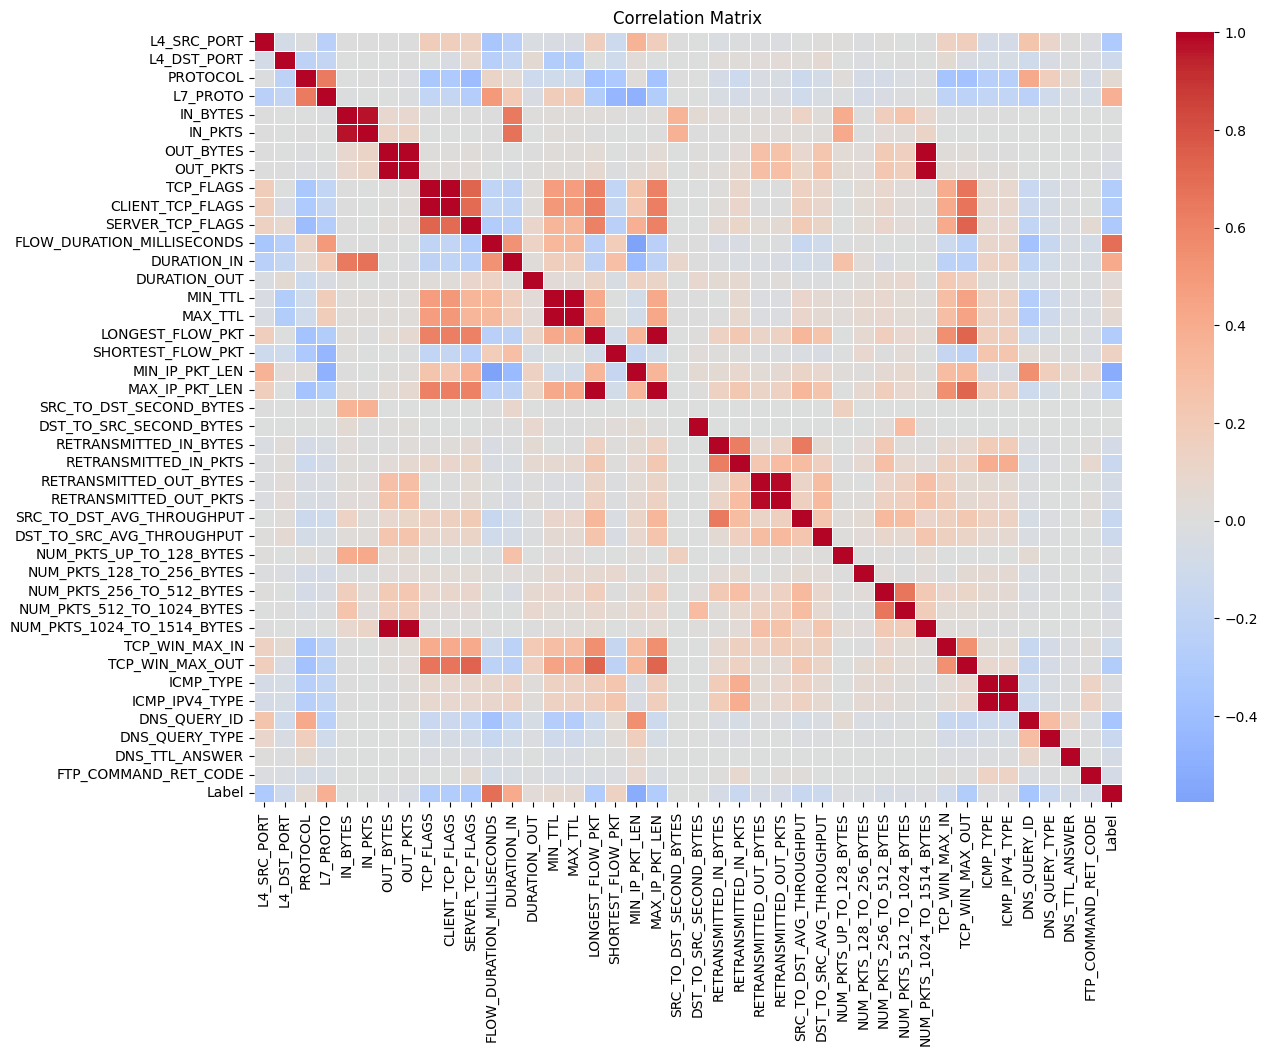

In [11]:
plt.figure(figsize=(14,10))
corr = df_sample.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.show()

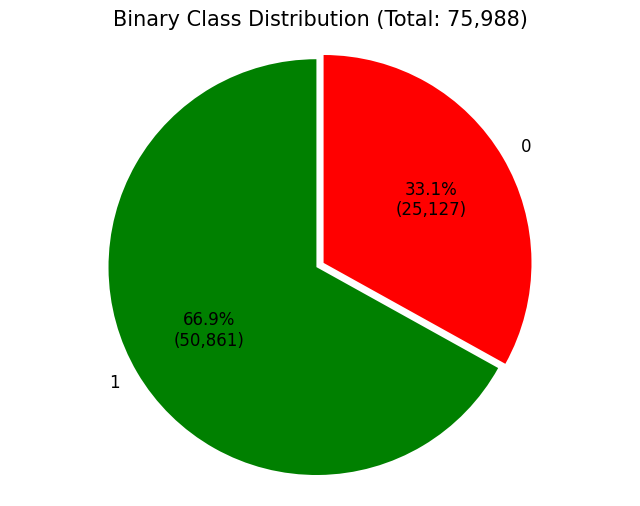

In [12]:
def autopct_format(values):
    def inner(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f'{pct:.1f}%\n({val:,})'
    return inner

# ambil data label
label_counts = df_sample["Label"].value_counts()

labels = label_counts.index.astype(str)
sizes = label_counts.values
colors = ["green", "red"]

plt.figure(figsize=(8, 6))

plt.pie(
    sizes,
    labels=labels,
    autopct=autopct_format(sizes),
    colors=colors,
    startangle=90,
    explode=[0.02] * len(labels),
    textprops={'fontsize': 12}
)

plt.title(f'Binary Class Distribution (Total: {label_counts.sum():,})', fontsize=15)

plt.axis('equal')
plt.show()

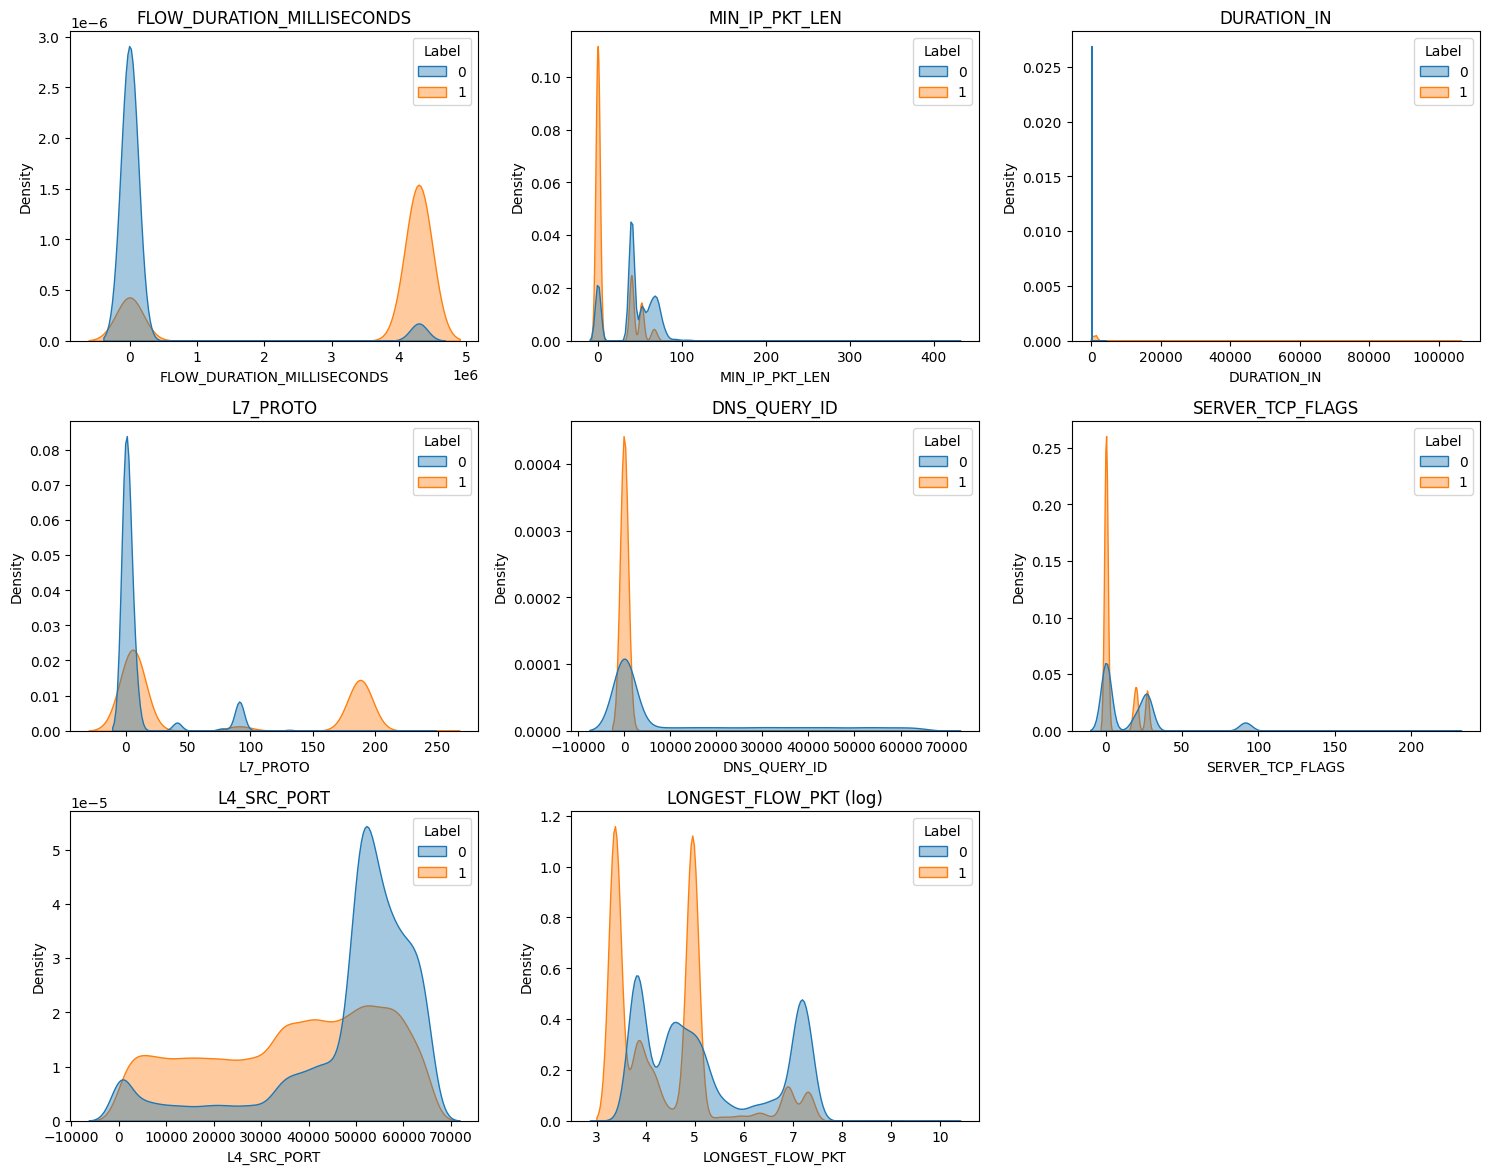

In [13]:
numeric_df = df_sample.select_dtypes(include=["int64", "float64"])

corr_with_label = (
    numeric_df
    .corr()["Label"]
    .abs()
    .sort_values(ascending=False)
)

top_features = corr_with_label.index[1:9]
n_cols = 3
n_rows = int(np.ceil(len(top_features) / n_cols))
plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(top_features):
    plt.subplot(n_rows, n_cols, i + 1)

    values = df_sample[col]

    if (values > 0).all():
        values = np.log1p(values)
        title = f"{col} (log)"
    else:
        title = col

    sns.kdeplot(
        x=values,
        hue=df_sample["Label"],
        common_norm=False,
        fill=True,
        alpha=0.4
    )

    plt.title(title)

plt.tight_layout()
plt.show()

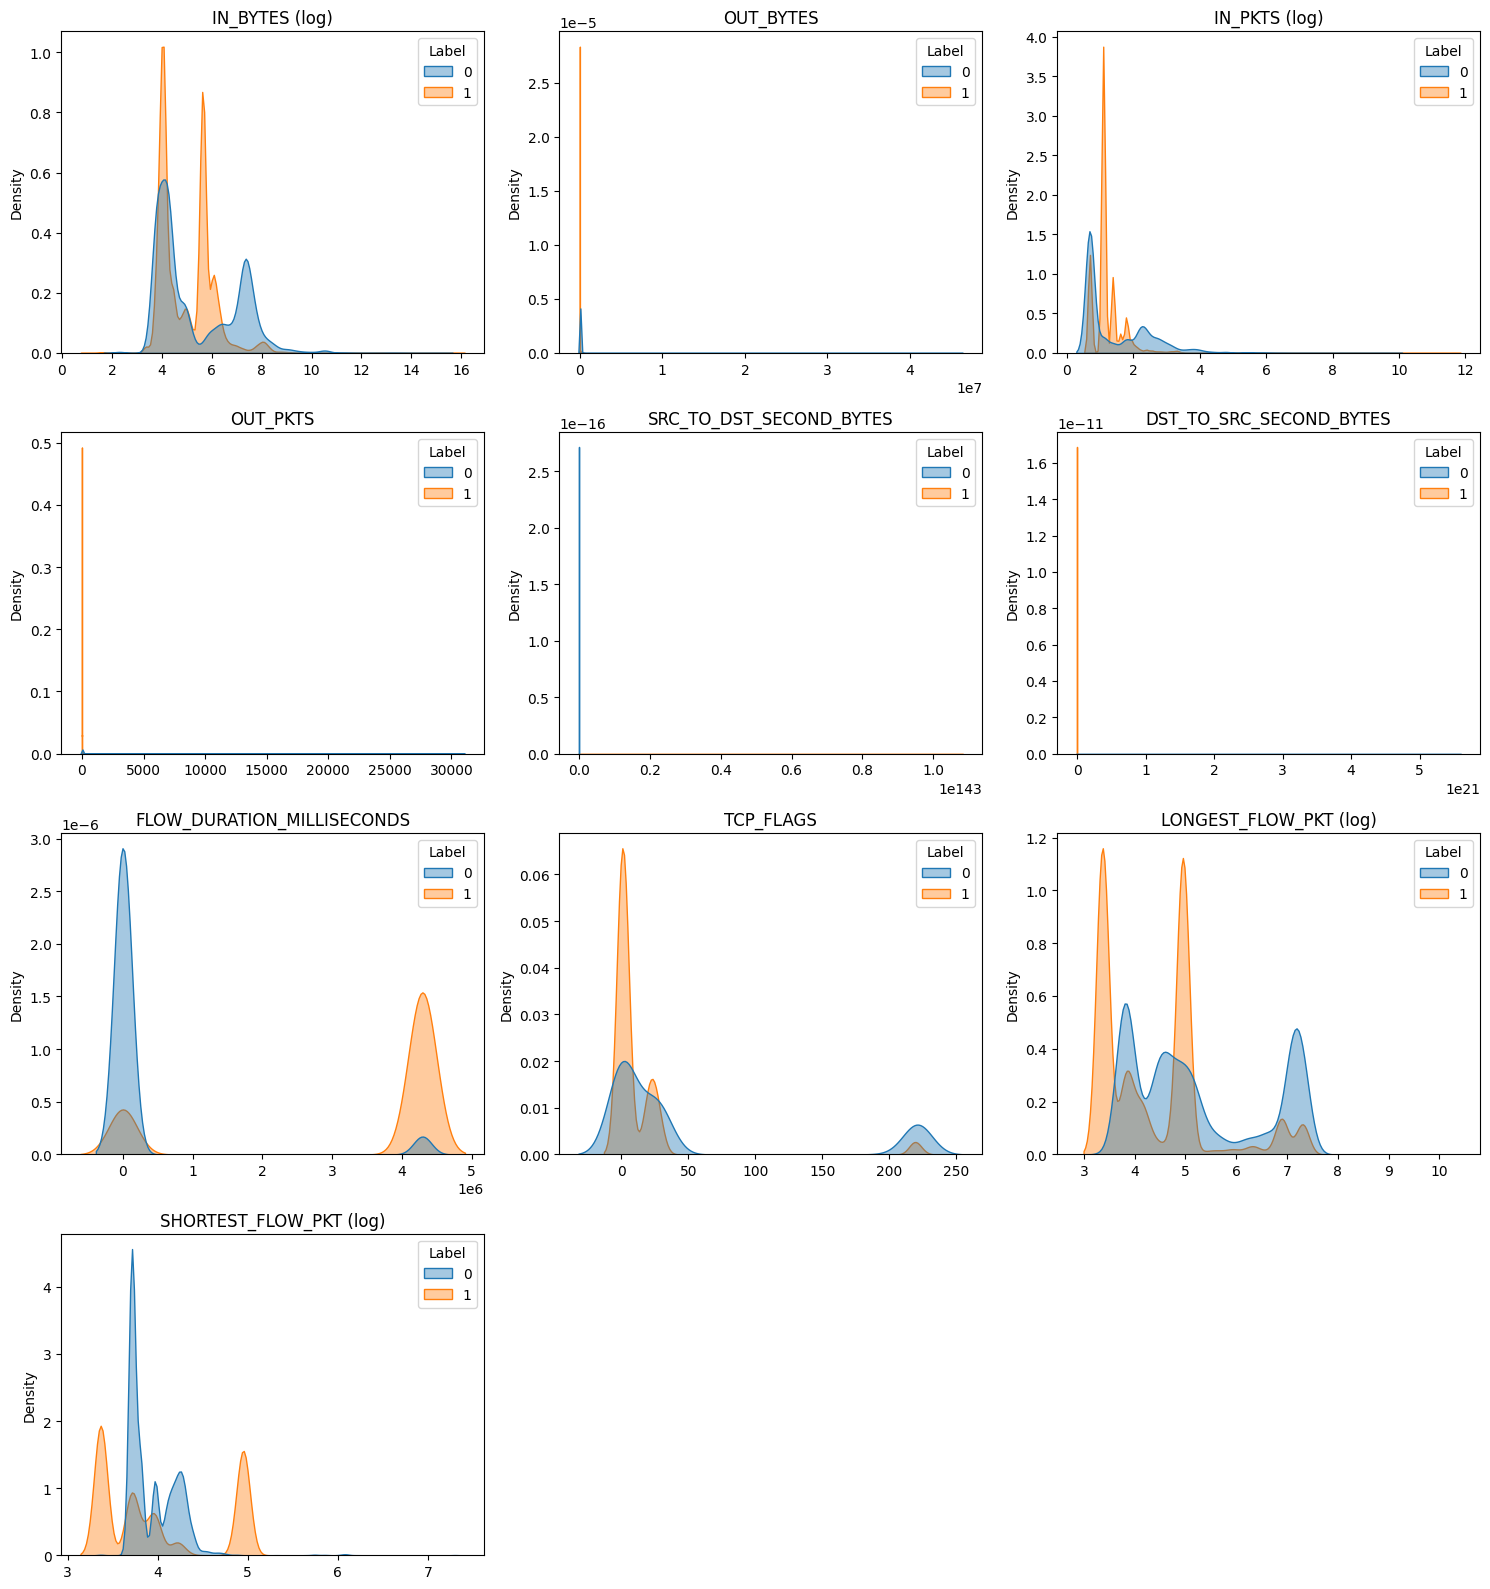

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# Top 10 Features You Selected
# ==============================

top_features = [
    "IN_BYTES",
    "OUT_BYTES",
    "IN_PKTS",
    "OUT_PKTS",
    "SRC_TO_DST_SECOND_BYTES",
    "DST_TO_SRC_SECOND_BYTES",
    "FLOW_DURATION_MILLISECONDS",
    "TCP_FLAGS",
    "LONGEST_FLOW_PKT",
    "SHORTEST_FLOW_PKT"
]

# Keep only numeric columns
numeric_df = df_sample.select_dtypes(include=["int64", "float64"])

# Clean data
numeric_df.replace([np.inf, -np.inf], np.nan, inplace=True)
numeric_df.fillna(0, inplace=True)

# ==============================
# Plot Layout
# ==============================

n_cols = 3
n_rows = int(np.ceil(len(top_features) / n_cols))

plt.figure(figsize=(15, 4 * n_rows))

# ==============================
# Plot Loop
# ==============================

for i, col in enumerate(top_features):

    if col not in numeric_df.columns:
        continue

    plt.subplot(n_rows, n_cols, i + 1)

    values = numeric_df[col]

    # Log transform for skewed positive features
    if (values > 0).all():
        values = np.log1p(values)
        title = f"{col} (log)"
    else:
        title = col

    sns.kdeplot(
        x=values,
        hue=df_sample["Label"],
        common_norm=False,
        fill=True,
        alpha=0.4
    )

    plt.title(title)
    plt.xlabel("")
    plt.ylabel("Density")

plt.tight_layout()
plt.show()


In [15]:
from sklearn.feature_selection import f_classif

X = numeric_df[top_features]
y = df_sample["Label"]

f_scores, p_values = f_classif(X, y)

anova_df = pd.DataFrame({
    "Feature": top_features,
    "F_score": f_scores,
    "p_value": p_values
})

anova_df = anova_df.sort_values(
    by="F_score",
    ascending=False
)

print(anova_df)


                      Feature       F_score       p_value
6  FLOW_DURATION_MILLISECONDS  67768.254413  0.000000e+00
8            LONGEST_FLOW_PKT   6628.998669  0.000000e+00
7                   TCP_FLAGS   6442.539056  0.000000e+00
9           SHORTEST_FLOW_PKT   1663.395304  0.000000e+00
3                    OUT_PKTS     79.961684  3.900548e-19
1                   OUT_BYTES     31.190877  2.346597e-08
5     DST_TO_SRC_SECOND_BYTES      2.024205  1.548140e-01
0                    IN_BYTES      1.075144  2.997897e-01
4     SRC_TO_DST_SECOND_BYTES      0.494029  4.821375e-01
2                     IN_PKTS      0.140960  7.073297e-01


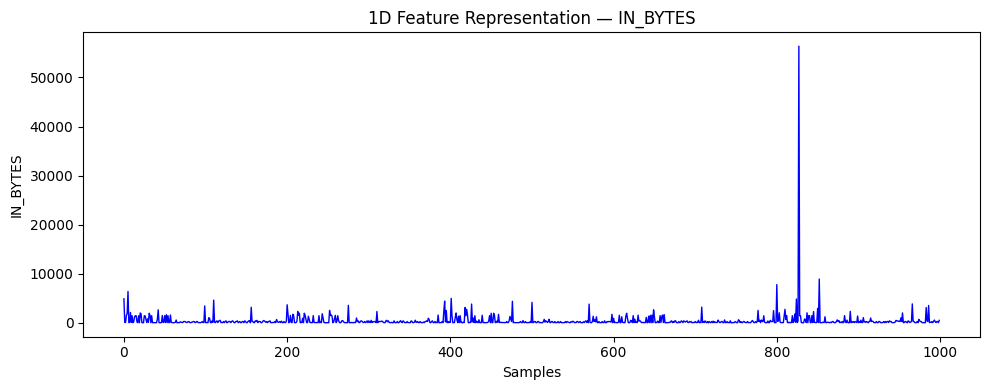

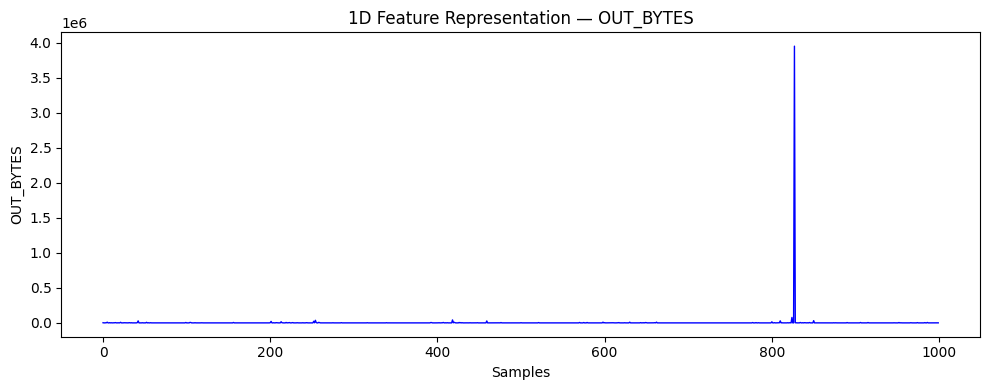

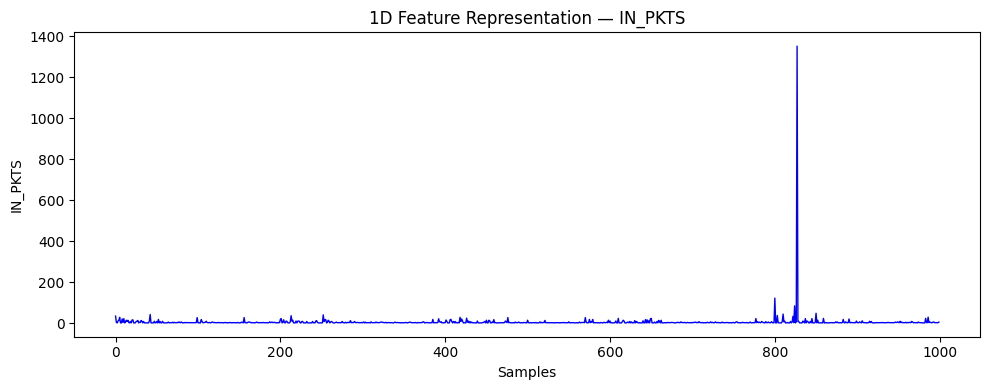

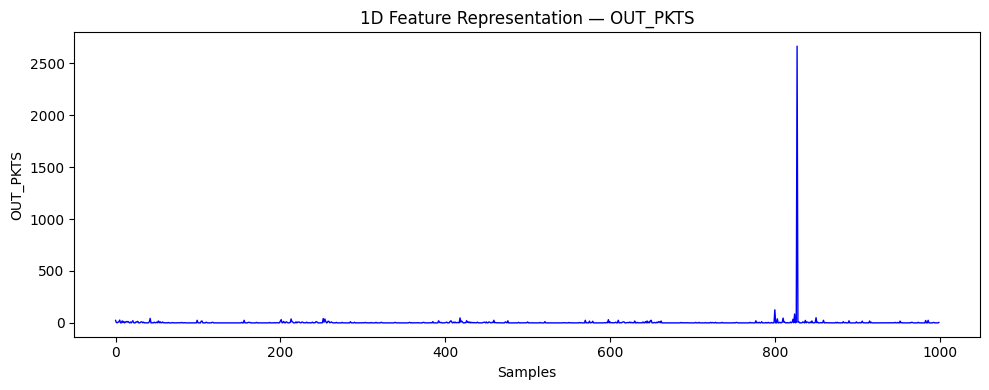

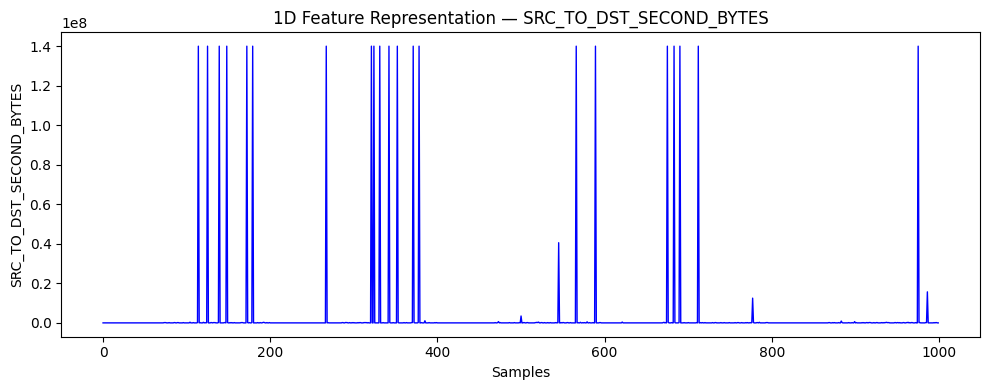

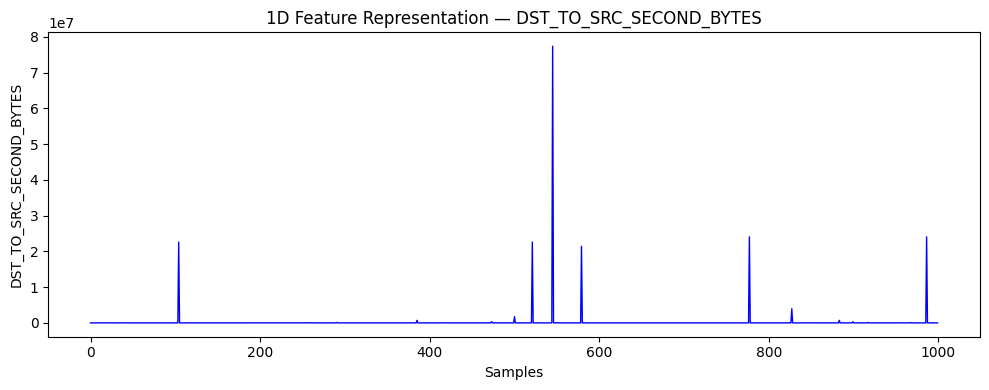

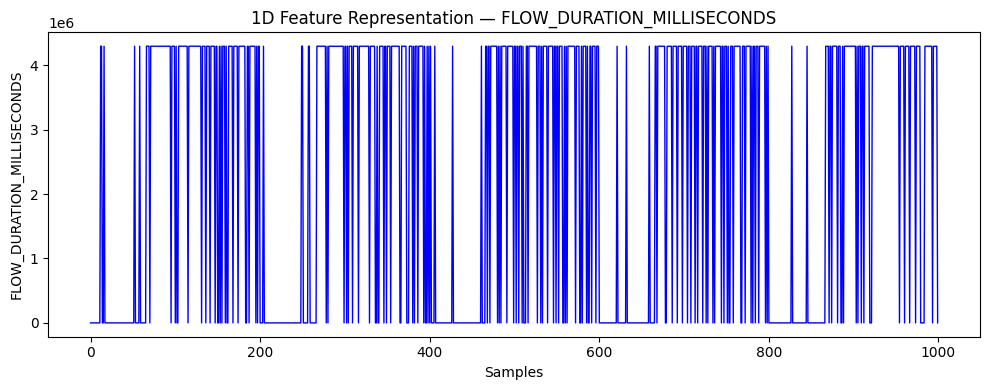

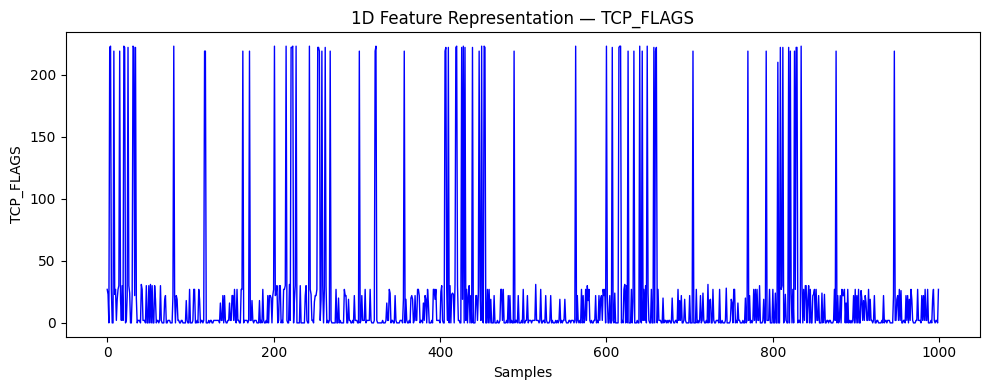

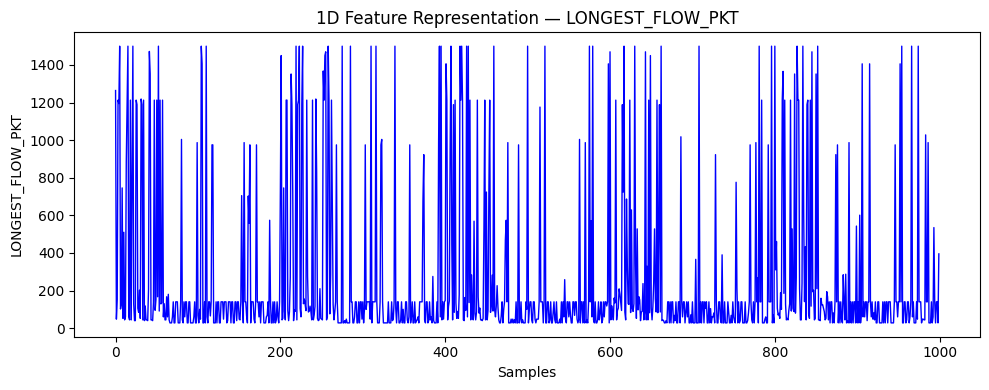

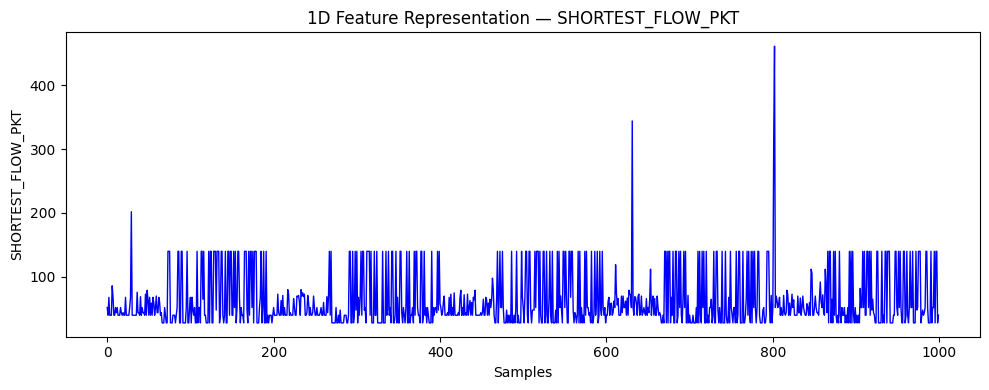

In [16]:
import matplotlib.pyplot as plt

for col in top_features:

    if col not in numeric_df.columns:
        continue

    plt.figure(figsize=(10,4))

    values = numeric_df[col].values[:1000]  # first 1000 samples

    plt.plot(values, color="blue", linewidth=1)

    plt.title(f"1D Feature Representation — {col}")
    plt.xlabel("Samples")
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

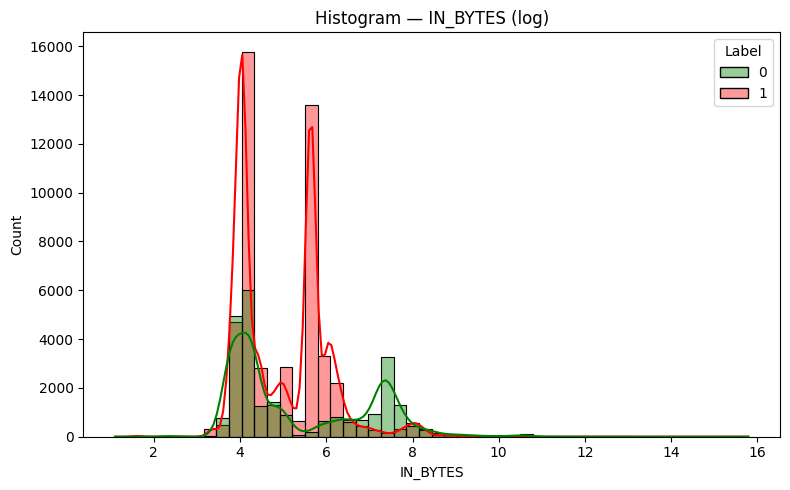

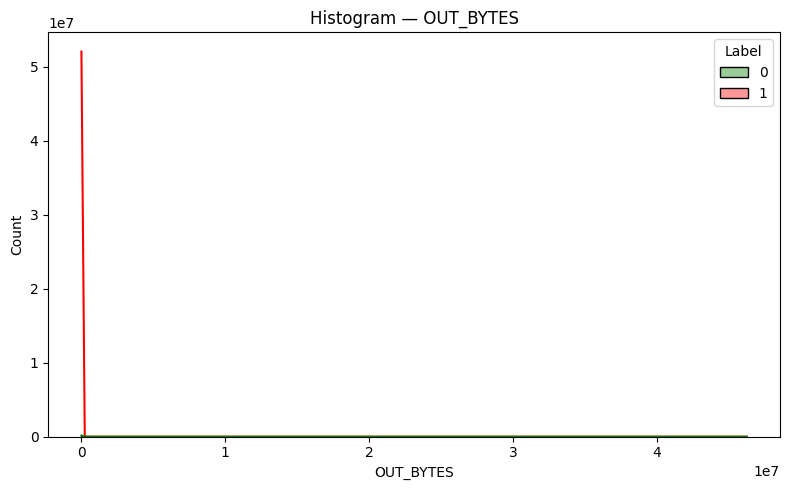

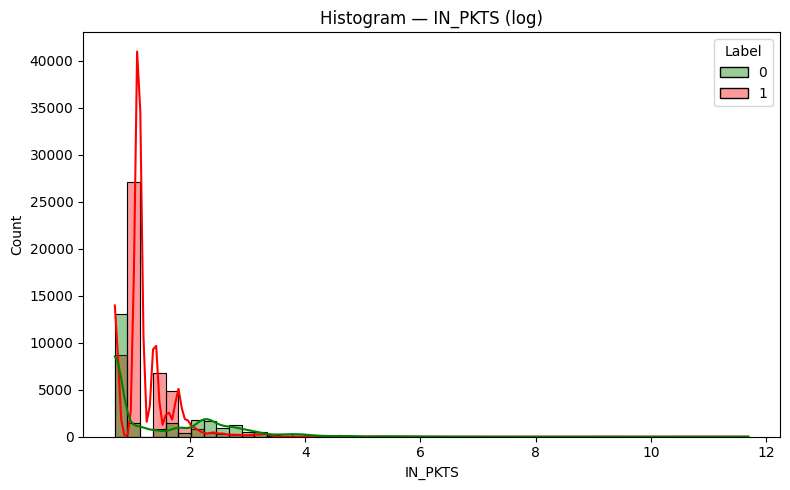

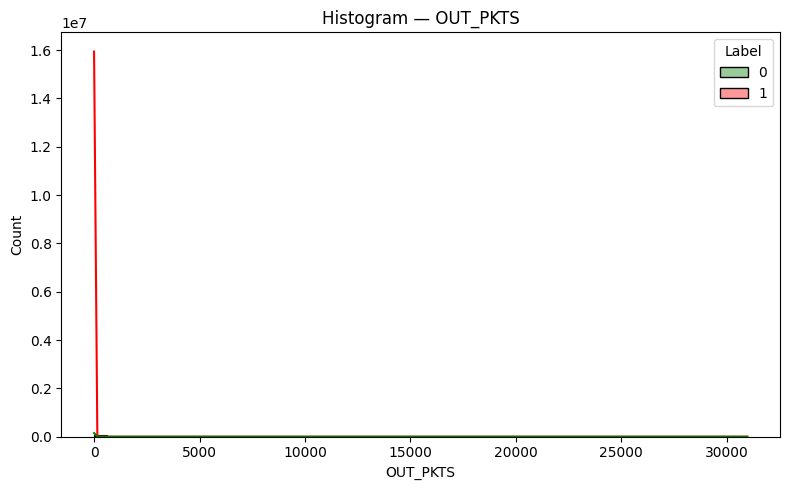

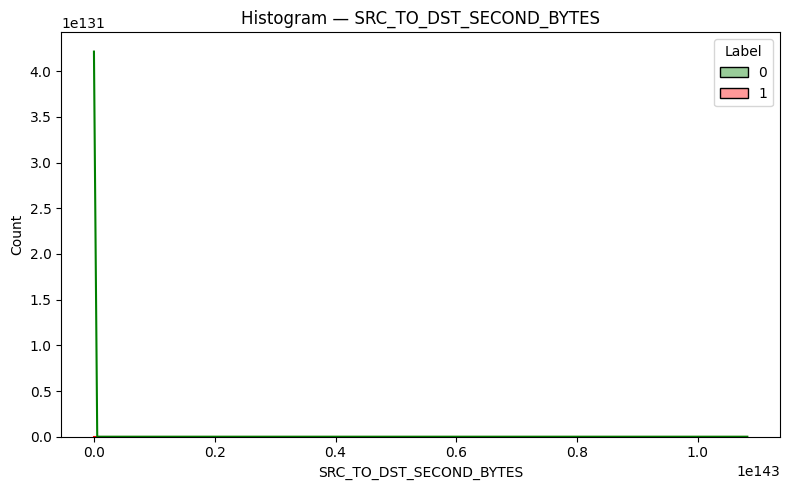

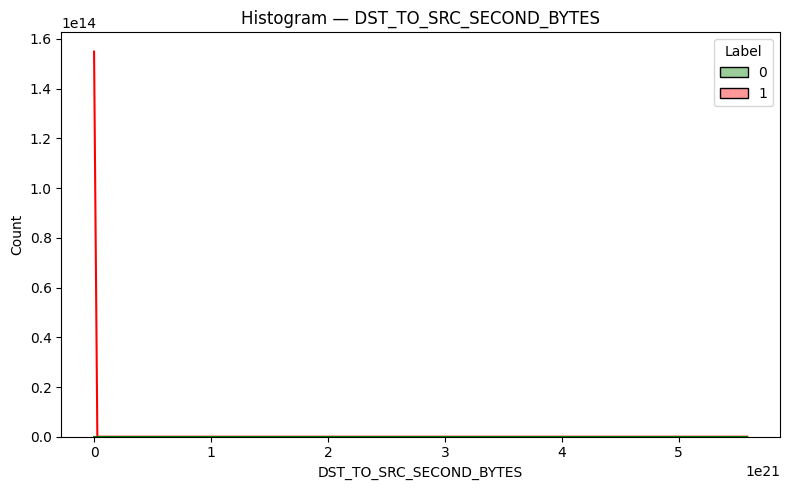

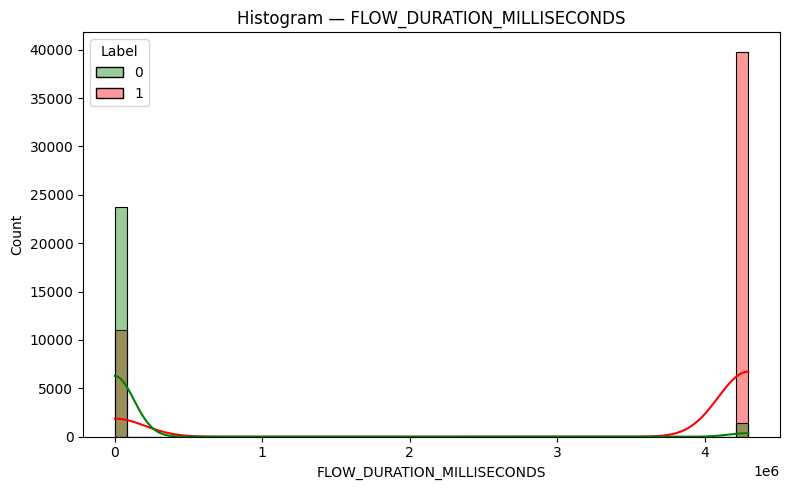

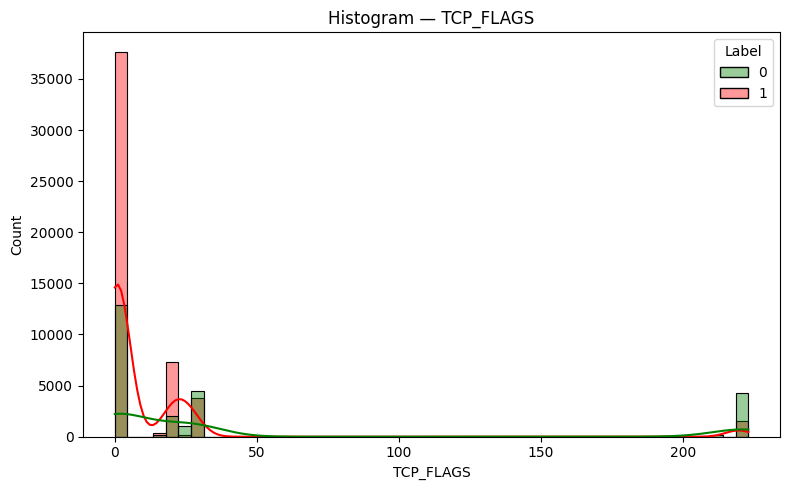

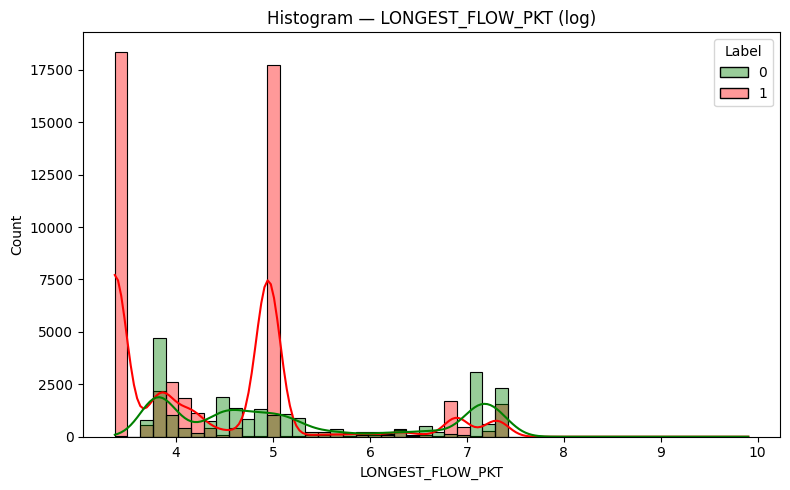

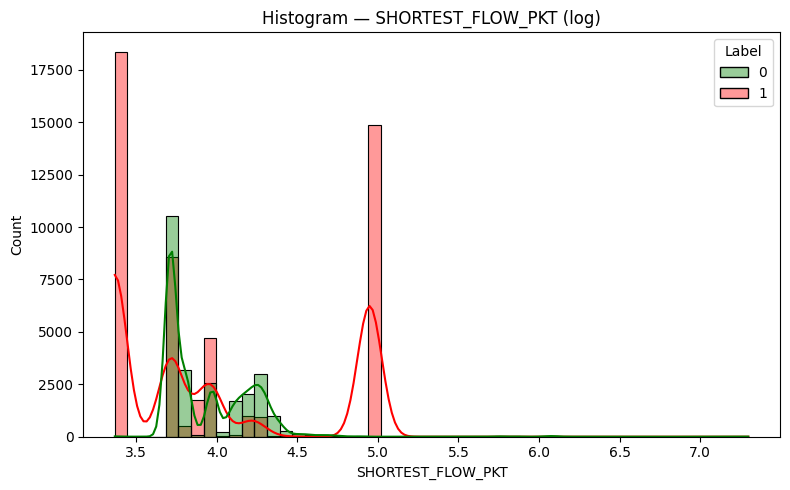

In [17]:
import seaborn as sns

for col in top_features:

    if col not in numeric_df.columns:
        continue

    plt.figure(figsize=(8,5))

    values = numeric_df[col]

    if (values > 0).all():
        values_plot = np.log1p(values)
        title = f"{col} (log)"
    else:
        values_plot = values
        title = col

    sns.histplot(
        x=values_plot,
        hue=df_sample["Label"],
        bins=50,
        kde=True,
        palette=["green", "red"],
        alpha=0.4
    )

    plt.title(f"Histogram — {title}")
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.tight_layout()
    plt.show()


In [18]:
top_features = [
    "IN_BYTES",
    "OUT_BYTES",
    "IN_PKTS",
    "OUT_PKTS",
    "SRC_TO_DST_SECOND_BYTES",
    "DST_TO_SRC_SECOND_BYTES",
    "FLOW_DURATION_MILLISECONDS",
    "TCP_FLAGS",
    "LONGEST_FLOW_PKT",
    "SHORTEST_FLOW_PKT"
]
